<a href="https://colab.research.google.com/github/HarshaSatyavardhan/cp/blob/main/KDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
samples = np.array([-2.0, -1.5, -1.0, 1.0, 1.5, 2.0])

In [12]:
samples

array([-2. , -1.5, -1. ,  1. ,  1.5,  2. ])

In [13]:
x_grid = np.linspace(-4, 4, 500)


In [23]:
def guassian_kernel(u):
  return (1/np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

In [15]:
h = 0.5

In [16]:
xi = samples[0]
xi

np.float64(-2.0)

In [18]:
u = (x_grid - xi) / h

In [19]:
kernel_values = guassian_kernel(u)

In [20]:
single_density = kernel_values / h

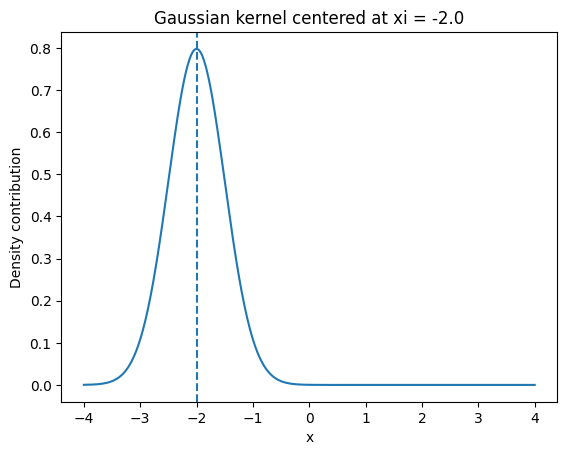

In [21]:
plt.plot(x_grid, single_density)
plt.axvline(xi, linestyle="--")

plt.xlabel("x")
plt.ylabel("Density contribution")
plt.title(f"Gaussian kernel centered at xi = {xi}")

plt.show()

In [24]:
kde_sum = np.zeros_like(x_grid)

for xi in samples:
    u = (x_grid - xi) / h
    kde_sum += guassian_kernel(u) / h

In [25]:
kde = kde_sum / len(samples)

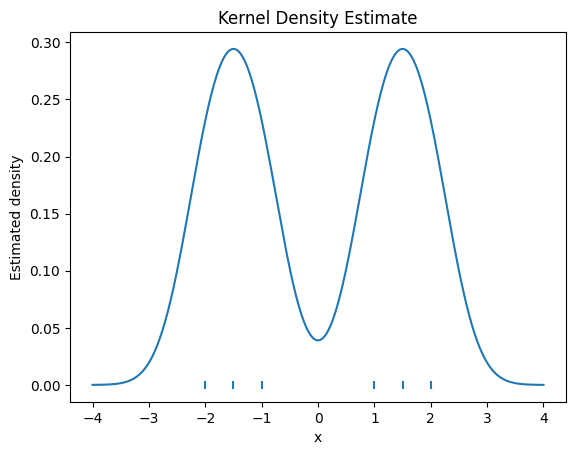

In [26]:
plt.plot(x_grid, kde)
plt.scatter(samples, np.zeros_like(samples), marker="|")

plt.xlabel("x")
plt.ylabel("Estimated density")
plt.title("Kernel Density Estimate")

plt.show()

In [27]:
xi = np.random.choice(samples)

print("Selected sample:", xi)

Selected sample: 2.0


In [28]:
noise = np.random.normal(loc=0, scale=h)

new_sample = xi + noise

print("Noise:", noise)
print("New KDE sample:", new_sample)

Noise: -0.6526055973452307
New KDE sample: 1.3473944026547693


In [29]:
n_new = 1000

selected_points = np.random.choice(samples, size=n_new)
noise = np.random.normal(loc=0, scale=h, size=n_new)

new_samples = selected_points + noise

print(new_samples[:10])

[ 1.72378289 -1.43875767 -1.25759234  1.51754006 -0.86506683 -2.79809184
  1.68017077  0.26994011  1.93196323  2.72788428]


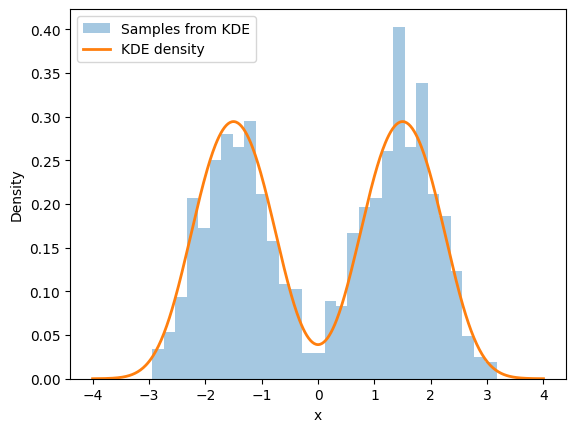

In [30]:
plt.hist(new_samples, bins=30, density=True, alpha=0.4, label="Samples from KDE")
plt.plot(x_grid, kde, linewidth=2, label="KDE density")

plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

In [31]:
from torchvision.datasets import MNIST
from torchvision import transforms

dataset = MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

print("Number of images:", len(dataset))
print("Image shape:", dataset[0][0].shape)
print("Label:", dataset[0][1])

100%|██████████| 9.91M/9.91M [00:00<00:00, 97.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 23.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 101MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.57MB/s]


Number of images: 60000
Image shape: torch.Size([1, 28, 28])
Label: 5


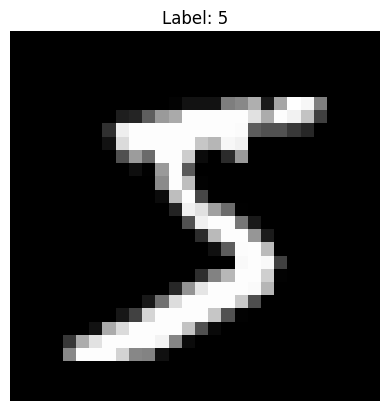

In [32]:
image, label = dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [33]:
import torch

n_samples = 5000

images = torch.stack([dataset[i][0] for i in range(n_samples)])
labels = torch.tensor([dataset[i][1] for i in range(n_samples)])

images_flat = images.view(n_samples, -1)

print("Original shape:", images.shape)
print("Flattened shape:", images_flat.shape)

Original shape: torch.Size([5000, 1, 28, 28])
Flattened shape: torch.Size([5000, 784])


In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

images_2d = pca.fit_transform(images_flat.numpy())

print("Reduced shape:", images_2d.shape)

Reduced shape: (5000, 2)


In [35]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(
    kernel="gaussian",
    bandwidth=1.0
)

kde.fit(images_2d)

KernelDensity()

In [36]:
x_min, x_max = images_2d[:, 0].min() - 5, images_2d[:, 0].max() + 5
y_min, y_max = images_2d[:, 1].min() - 5, images_2d[:, 1].max() + 5

x_grid, y_grid = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points = np.column_stack([
    x_grid.ravel(),
    y_grid.ravel()
])

log_density = kde.score_samples(grid_points)
density = np.exp(log_density).reshape(x_grid.shape)

print(density.shape)

(200, 200)


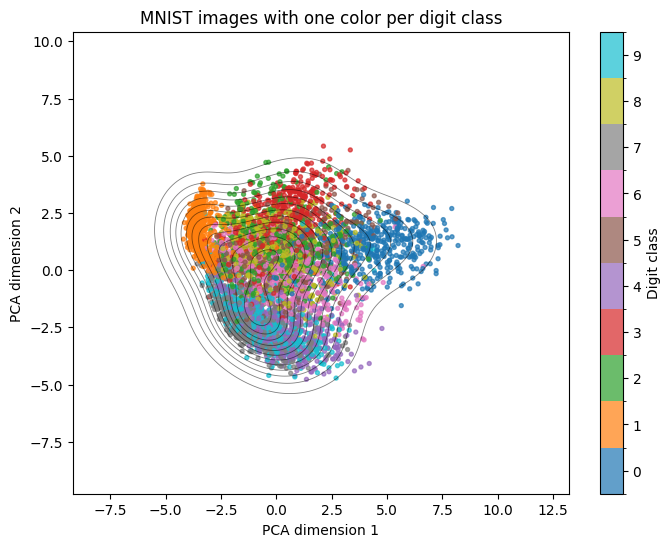

In [38]:
from matplotlib.colors import BoundaryNorm

cmap = plt.get_cmap("tab10", 10)
norm = BoundaryNorm(np.arange(-0.5, 10.5), cmap.N)

plt.figure(figsize=(8, 6))

# KDE shown only as contour lines
plt.contour(
    x_grid,
    y_grid,
    density,
    levels=12,
    colors="black",
    linewidths=0.6,
    alpha=0.5
)

scatter = plt.scatter(
    images_2d[:, 0],
    images_2d[:, 1],
    c=labels.numpy(),
    cmap=cmap,
    norm=norm,
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, ticks=range(10), label="Digit class")
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.title("MNIST images with one color per digit class")
plt.show()